# EDA Mac

In [67]:
from IPython.display import SVG, display, HTML
import cairosvg
from IPython.display import Image
import io
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [68]:
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

train_df.shape

(50000, 3)

## View Distributions

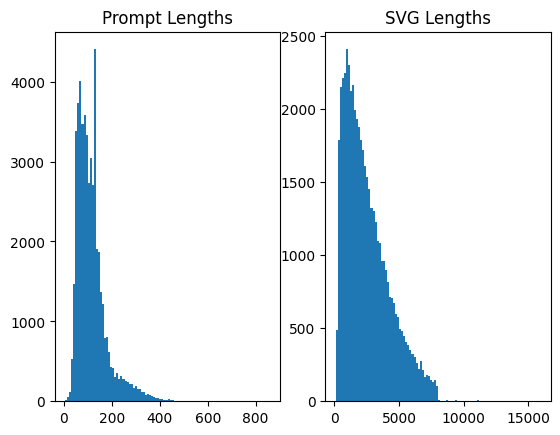

In [69]:
prompt_lengths = train_df['prompt'].apply(lambda x : len(x))
svg_lengths = train_df['svg'].apply(lambda x : len(x))
fig, ax = plt.subplots(1, 2)
ax[0].hist(prompt_lengths, bins=100)
ax[0].set_title('Prompt Lengths')
ax[1].hist(svg_lengths, bins=100)
ax[1].set_title('SVG Lengths')
plt.show()

In [70]:
ALL_COLORS = ['black', 'white', 'grey', 'gray', 'red', 'blue', 'orange', 'yellow', 'green', 'purple', 'pink']
# COLORS = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
COLORS = ['red', 'blue', 'orange', 'yellow', 'green', 'purple', 'pink']
def get_color_dist(df:pd.DataFrame, text):
    for c in ALL_COLORS:
        # Counts the number of rows that have a certain color
        print(f'{text}: ', c, sum(df['prompt'].apply(lambda x: c in x)))
    
# colors = ['black', 'white', 'grey', 'gray', 'red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
# for c in colors:
#     print('Train DF Prompt: ', c, sum(train_df['prompt'].apply(lambda x: c in x)))
# for c in colors:
#     print('Train DF SVG: ', c, sum(train_df['svg'].apply(lambda x: c in x)))
get_color_dist(train_df, 'train')
get_color_dist(test_df, 'test')

train:  black 27886
train:  white 28165
train:  grey 80
train:  gray 4523
train:  red 8031
train:  blue 6469
train:  orange 1376
train:  yellow 1440
train:  green 1327
train:  purple 687
train:  pink 783
test:  black 531
test:  white 553
test:  grey 1
test:  gray 94
test:  red 155
test:  blue 137
test:  orange 31
test:  yellow 26
test:  green 36
test:  purple 21
test:  pink 18


## Color Tweeking Results

In [71]:
# Original data sample
# old_train_sample = train_df.loc[210, :]
prompt_svg_sample = train_df.iloc[30]
# old_train_sample = train_df.iloc[300]
print(prompt_svg_sample['prompt'],'\n\n', prompt_svg_sample['svg'])


The image shows a black padlock icon on a white background, featuring a rectangular body and a curved shackle with a circular keyhole in the center. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#333333" fill-opacity="1.0"  filling="0" d="M158.126953125 75.18203735351562 L57.69023132324219 75.18203735351562 L57.69023132324219 58.53964614868164 A41.89726638793945 41.89726638793945 0.0 1 1 141.4845733642578 58.53964614868164 A8.3212890625 8.3212890625 0.0 0 0 158.126953125 58.53964614868164 A58.53964614868164 58.53964614868164 0.0 1 0 41.047847747802734 58.53964614868164 L41.047847747802734 75.18203735351562 A24.963672637939453 24.963672637939453 0.0 0 0 16.666603088378906 100.14569854736328 L16.666603088378906 175.03631591796875 A24.963672637939453 24.963672637939453 0.0 0 0 41.63027572631836 200.0 L158.126953125 200.0 A24.963672637939453 24.963672637939453 0.0 0 0 183.09063720703125 175.03631591796875 L183.09063720

The image shows a stylized blue chart icon with ascending bars and an upward-pointing arrow, representing growth or increase. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#00A3EB" fill-opacity="1.0"  filling="0" d="M54.87109375 152.07559204101562 A4.444531440734863 4.444531440734863 0.0 0 1 54.5400390625 143.19784545898438 L54.87324142456055 143.1867218017578 L71.19551086425781 143.1843719482422 L71.19551086425781 117.3267593383789 A4.444531440734863 4.444531440734863 0.0 0 1 80.0732421875 116.99335479736328 L80.08438110351562 117.3267593383789 L80.08438110351562 143.1843719482422 L89.6578140258789 143.1843719482422 L89.6578140258789 101.0111312866211 A4.444531440734863 4.444531440734863 0.0 0 1 98.53555297851562 100.67772674560547 L98.54667663574219 101.0111312866211 L98.54667663574219 143.1843719482422 L108.11776733398438 143.1843719482422 L108.11776733398438 110.3333969116211 A4.444531440734863 4.44453144073486

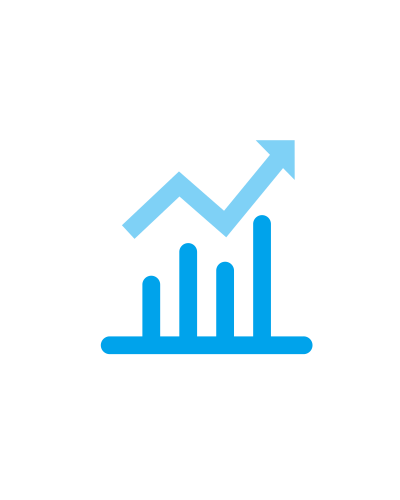

SVG source: 2009 characters
PNG output:  7,164 bytes


In [72]:
# old_train_sample = train_df.iloc[33]
old_train_sample = train_df.sample().iloc[0]

def get_svg_image(prompt_svg_sample:pd.Series):
    print(prompt_svg_sample['prompt'],'\n\n', prompt_svg_sample['svg'])

    # Render SVG to PNG using cairosvg
    png_bytes = cairosvg.svg2png(bytestring=prompt_svg_sample['svg'].encode('utf-8'),
                                output_width=400, output_height=500)

    # Display the rasterized version
    display(Image(data=png_bytes, format='png'))
    print(f"SVG source: {len(prompt_svg_sample['svg'])} characters")
    print(f"PNG output:  {len(png_bytes):,} bytes")
get_svg_image(old_train_sample)

Replace the coloring

#05A7F2
#82D5FC
The image shows a stylized blue chart icon with ascending bars and an upward-pointing arrow, representing growth or increase. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#05A7F2" fill-opacity="1.0"  filling="0" d="M54.87109375 152.07559204101562 A4.444531440734863 4.444531440734863 0.0 0 1 54.5400390625 143.19784545898438 L54.87324142456055 143.1867218017578 L71.19551086425781 143.1843719482422 L71.19551086425781 117.3267593383789 A4.444531440734863 4.444531440734863 0.0 0 1 80.0732421875 116.99335479736328 L80.08438110351562 117.3267593383789 L80.08438110351562 143.1843719482422 L89.6578140258789 143.1843719482422 L89.6578140258789 101.0111312866211 A4.444531440734863 4.444531440734863 0.0 0 1 98.53555297851562 100.67772674560547 L98.54667663574219 101.0111312866211 L98.54667663574219 143.1843719482422 L108.11776733398438 143.1843719482422 L108.11776733398438 110.3333969116211 A4.444531440734863 

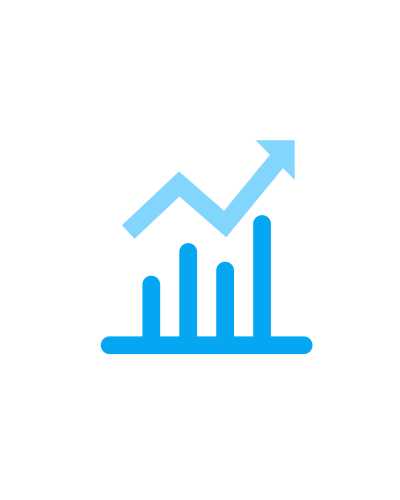

SVG source: 2009 characters
PNG output:  7,073 bytes


In [73]:
import re

# BO_WG_color_mapping = {
#     'black' : ['orange', ['"#000000"', '"0"'], '"#FF6A00"'],
#     'white' : ['green', ['"#FFFFFF"', '"#FFFFFF"'], '"#00FF00"'],
# }
# def replace_color(str:str, color_map):
#     # Simple replace does not work across colors, too many different formats, and such. 
#     for k in list(color_map.keys()):
#         # Replace Prompt
#         str = str.replace(k, color_map[k][0])
#         # Replace hex RGB
#         str = str.replace(color_map[k][1][0], color_map[k][2])
#         str = str.replace(color_map[k][1][1], color_map[k][2])
#     return str

def color_tweek(str:str):
    """
    We want to increase the number of colored examples, so we want to slightly adjust the colored values only
    This function only increments the color values by a random amount evenly
    """
    def adjust_color(match:re.Match):
        # noise = np.random.randint(0, 100)
        # noise = np.random.randint(0, 10)
        noise = 10
        color = match.group(0)
        if color.lower() in ['#000000', '#ffffff']:
            return color
        r = int(color[1:3], 16)
        g = int(color[3:5], 16)
        b = int(color[5:7], 16)
        # Slightly adjust by adding noise to each component
        # r = min(255, r + noise)
        # g = min(255, g + noise)
        # b = min(255, b + noise)
        r = min(255, r + np.random.randint(0, noise))
        g = min(255, g + np.random.randint(0, noise))
        b = min(255, b + np.random.randint(0, noise))
        print(f'#{r:02x}{g:02x}{b:02x}'.upper())
        return f'#{r:02x}{g:02x}{b:02x}'.upper()

    pattern = r'#[0-9a-fA-F]{6}'
    str = re.sub(pattern, adjust_color, str)
    return str

# new_train_sample = old_train_sample.apply(replace_color, args=(BO_WG_color_mapping,))
new_train_sample = old_train_sample.apply(color_tweek)

get_svg_image(new_train_sample)


## Tweek Colors Across dataframe

In [74]:
# # Replaced colors data
# def replace_BW_colors(df:pd.DataFrame, color_map):
#     new_df = df.copy()
#     new_df = new_df[new_df['prompt'].str.contains(r'(black)|(white)', case=False)]
#     new_df['prompt'] = new_df['prompt'].apply(replace_color, args=(color_map,))
#     new_df.reset_index(inplace=True, drop=True)
#     return new_df

COLORS_REGEX = f'({COLORS[0]})'
for c in COLORS[1:]:
    COLORS_REGEX += f'|({c})'

def df_tweek_colors(df:pd.DataFrame, color_list:list):
    """
    Returns a new dataframe, of rows that contain prompts with colors.
    Prompts with both BW and colors are included
    The color values in the svg have been tweeked by color_tweek.
    """
    new_df = df.copy()

    colors_regex = f'({color_list[0]})'
    for c in color_list[1:]:
        colors_regex += f'|({c})'
    # print(COLORS_REGEX) # Debug

    new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]
    new_df['prompt'] = new_df['prompt'].apply(color_tweek)
    new_df.reset_index(inplace=True, drop=True)
    return new_df

In [75]:
# color_train_df = replace_BW_colors(train_df, BO_WG_color_mapping)
# color_train_df

color_train_df = df_tweek_colors(train_df, COLORS)
color_train_df

/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/1400647033.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]


,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like...,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24..."
2,0e629ca90f9d3271dd224e2d6bd45b6e,A black-and-white icon depicting a secured win...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,4368171726accb70f7e5e2dcf7cc1c00,"A simple, green line drawing of a potted cactu...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
4,b4b9c86ee637c6d837a28340f3aafdf7,The image features a blue circular outline con...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
...,...,...,...
17221,thesantatitan_deepseek-svg-dataset_0000241,Generate svg code for an image that looks like...,"<svg width=""400"" height=""400"" viewBox=""0 0 400..."
17222,05c038b09bdf2b503b79a49d0d1ec031,A black and white illustration of a taxi with ...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
17223,77626302ad9e12887faac630f7c1b47d,The image features a light gray rectangle with...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
17224,d05c8a1ca1a2470557a08aeefe77e144,"A red mug with steam rising from it, symbolizi...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


### Checking Color Distributions

In [76]:
get_color_dist(color_train_df, 'color dist')

color dist:  black 6448
color dist:  white 8563
color dist:  grey 20
color dist:  gray 1358
color dist:  red 8031
color dist:  blue 6469
color dist:  orange 1376
color dist:  yellow 1440
color dist:  green 1327
color dist:  purple 687
color dist:  pink 783


In [77]:
# No black or white in the prompt
get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(r'(black)|(white)')], 'No B or W')

# Not Colors in the prompt
get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)], 'No Color')
color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)].iloc[0, 1]
# The regex expression not perfect, need escape char for 'red\W'.

No B or W:  black 0
No B or W:  white 0
No B or W:  grey 16
No B or W:  gray 645
No B or W:  red 1565
No B or W:  blue 3809
No B or W:  orange 777
No B or W:  yellow 870
No B or W:  green 814
No B or W:  purple 436
No B or W:  pink 492
No Color:  black 27
No Color:  white 26
No Color:  grey 1
No Color:  gray 1
No Color:  red 0
No Color:  blue 0
No Color:  orange 0
No Color:  yellow 0
No Color:  green 0
No Color:  purple 0
No Color:  pink 0


/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/3644818561.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(r'(black)|(white)')], 'No B or W')
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/3644818561.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)], 'No Color')
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/3644818561.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)].iloc[0, 1]


'The image features a black circular background with a white Reddit alien mascot icon in the center, including its antenna and smiling face.'

The image features a stylized blue human figure icon centered within a black rectangular frame. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#474747" fill-opacity="1.0"  filling="0" d="M175.5400390625 77.6900405883789 A6.0 6.0 0.0 0 1 169.5400390625 71.6900405883789 L169.5400390625 38.55000305175781 A9.56992244720459 9.56992244720459 0.0 0 0 160.0 29.0 L126.58008575439453 29.0 A6.0 6.0 0.0 0 1 126.58008575439453 17.0 L160.0 17.0 A21.590038299560547 21.590038299560547 0.0 0 1 181.56991577148438 38.559959411621094 L181.56991577148438 71.6900405883789 A6.0 6.0 0.0 0 1 175.5400390625 77.6900405883789 Z M159.85000610351562 180.30996704101562 L126.7099609375 180.30996704101562 A6.0 6.0 0.0 1 1 126.7099609375 168.30996704101562 L159.85000610351562 168.30996704101562 A9.56992244720459 9.56992244720459 0.0 0 0 169.40997314453125 158.75 L169.40997314453125 125.3599624633789 A6.0 6.0 0.0 1 1 181.4099578857422 125.35996246337

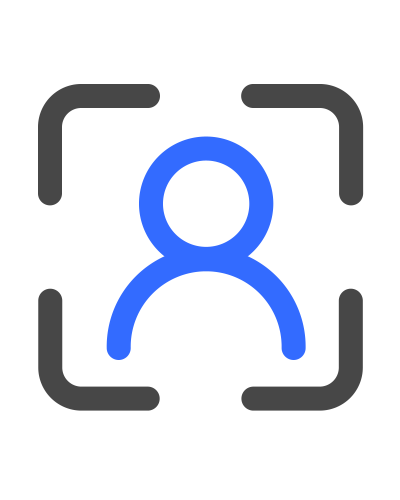

SVG source: 2604 characters
PNG output:  14,165 bytes


In [78]:
img_sample = color_train_df.iloc[13, :]

get_svg_image(img_sample)

## Creating Final Appended Color Dataset

In [79]:
get_color_dist(train_df, 'train')
# Colors are not evenly distributed
# red, blue, > orange, yellow, green, > purple, pink

train:  black 27886
train:  white 28165
train:  grey 80
train:  gray 4523
train:  red 8031
train:  blue 6469
train:  orange 1376
train:  yellow 1440
train:  green 1327
train:  purple 687
train:  pink 783


In [80]:
# all_color_mappers = [
#     {
#         'black' : ['orange', '#000000', '#FF6A00'],
#         'white' : ['green', '#FFFFFF', "#00FF00"],
#     },
#     {
#         'black' : ['yellow', '#000000', "#FFEE00"],
#         'white' : ['purple', '#FFFFFF', "#950095"],
#     },
#     {
#         'black' : ['blue', '#000000', "#0000FF"],
#         'white' : ['gray', '#FFFFFF', "#888888"],
#     },
#     {
#         'black' : ['grey', '#000000', "#888888"],
#         'white' : ['pink', '#FFFFFF', "#FF00FF"],
#     }
# ]

# final_colors_df = []
# for i in range(len(all_color_mappers)):
#     final_colors_df.append(replace_BW_colors(train_df, all_color_mappers[i]))
# final_colors_df = pd.concat(final_colors_df)
# final_colors_df.shape, train_df.shape, get_color_dist(final_colors_df, 'final_colors')


final_colors_df = []
# Colors are not evenly distributed
# red, blue, > orange, yellow, green, > purple, pink

for i in range(1):
    # red
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[1])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

for i in range(1):
    # blue
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[2])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

for i in range(10):
    # Orange Green Yellow
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[2:5])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

for i in range(20):
    # Purple and Pink
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[5:])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

final_colors_df = pd.concat(final_colors_df)
final_colors_df.reset_index(drop=True, inplace=True)
final_colors_df.shape, train_df.shape, get_color_dist(final_colors_df, 'final_colors')


/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/1400647033.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/3122676788.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/1400647033.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_90573/3122676788.py:42: UserWarning: Thi

final_colors:  black 0
final_colors:  white 0
final_colors:  grey 156
final_colors:  gray 7658
final_colors:  red 8390
final_colors:  blue 16028
final_colors:  orange 10384
final_colors:  yellow 12520
final_colors:  green 10568
final_colors:  purple 10502
final_colors:  pink 11724


((73612, 3), (50000, 3), None)

## Combining with Original Train, Control how many

In [81]:
# Sub Sample Distribution
final_colors_df.sample(25000).shape, get_color_dist(final_colors_df.sample(25000), 'final sample')

final sample:  black 0
final sample:  white 0
final sample:  grey 58
final sample:  gray 2534
final sample:  red 2873
final sample:  blue 5474
final sample:  orange 3518
final sample:  yellow 4267
final sample:  green 3655
final sample:  purple 3543
final sample:  pink 3954


((25000, 3), None)

In [82]:
# Colored distribution
final_combined_df = pd.concat([train_df, final_colors_df.sample(73612)])
get_color_dist(final_combined_df, 'final_combined_df'), final_combined_df.shape

final_combined_df:  black 27886
final_combined_df:  white 28165
final_combined_df:  grey 236
final_combined_df:  gray 12181
final_combined_df:  red 16421
final_combined_df:  blue 22497
final_combined_df:  orange 11760
final_combined_df:  yellow 13960
final_combined_df:  green 11895
final_combined_df:  purple 11189
final_combined_df:  pink 12507


(None, (123612, 3))

The image shows a calendar page with a beige background, a red number '1', a yellow horizontal line near the top, and two brown rings at the top center. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#F3DAB8" fill-opacity="1.0"  filling="0" d="M164.15390014648438 13.983009338378906 C181.1443328857422 13.983009338378906 194.93222045898438 27.770706176757812 194.93222045898438 44.761322021484375 L194.93222045898438 200.0 L5.263084411621094 200.0 L5.263084411621094 44.761322021484375 C5.263084411621094 27.770706176757812 19.05078125 13.983009338378906 36.041404724121094 13.983009338378906 L164.15390014648438 13.983009338378906 Z"></path>
<path fill="#CA3A2A" fill-opacity="1.0"  filling="0" d="M98.90644836425781 92.29570007324219 L89.2978515625 92.29570007324219 L89.2978515625 107.56757354736328 L98.90644836425781 107.56757354736328 L98.90644836425781 178.0099639892578 L114.1783218383789 178.0099639892578 L114.178321838

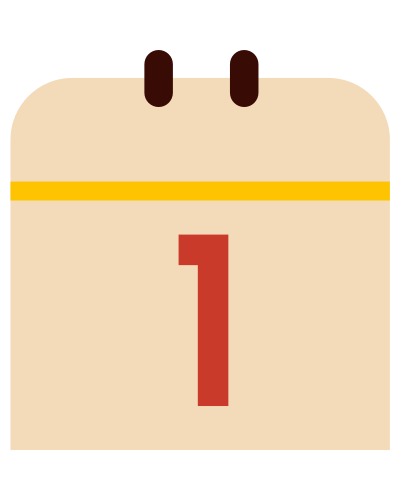

SVG source: 2676 characters
PNG output:  5,034 bytes


In [83]:
# Spam run to see samples
get_svg_image(final_colors_df.sample().iloc[0])

In [84]:
# Original training dataset stats
get_color_dist(train_df, 'train DF'), train_df.shape

train DF:  black 27886
train DF:  white 28165
train DF:  grey 80
train DF:  gray 4523
train DF:  red 8031
train DF:  blue 6469
train DF:  orange 1376
train DF:  yellow 1440
train DF:  green 1327
train DF:  purple 687
train DF:  pink 783


(None, (50000, 3))

In [85]:
final_combined_df.sample(100000).shape, get_color_dist(final_combined_df.sample(100000), 'final_combined_df')

final_combined_df:  black 22489
final_combined_df:  white 22644
final_combined_df:  grey 187
final_combined_df:  gray 9836
final_combined_df:  red 13235
final_combined_df:  blue 18305
final_combined_df:  orange 9540
final_combined_df:  yellow 11342
final_combined_df:  green 9651
final_combined_df:  purple 9013
final_combined_df:  pink 10167


((100000, 3), None)

In [86]:
# final_combined_df.sample(100000).to_csv('./dataset/final_combined_df_100000.csv')

In [87]:
final_combined_df.sample().iloc[0]['svg']

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#333333" fill-opacity="1.0"  filling="0" d="M149.04727172851562 35.85039520263672 C149.61190795898438 35.85039520263672 150.31756591796875 35.991600036621094 150.88223266601562 36.556053161621094 C152.4347686767578 38.10859298706055 152.15234375 40.790428161621094 150.88223266601562 42.06074523925781 C149.61190795898438 42.90761947631836 121.94784545898438 70.9951171875 121.94784545898438 70.9951171875 C121.94784545898438 70.9951171875 119.5484390258789 74.1001968383789 121.94784545898438 76.4996109008789 C122.79472351074219 77.34648132324219 123.64140319824219 77.62871551513672 124.48828125 77.62871551513672 C126.1820297241211 77.62871551513672 127.45234680175781 76.4996109008789 127.45234680175781 76.4996109008789 L158.64511108398438 47.847652435302734 C158.64511108398438 47.847652435302734 159.49180603027344 47.14179611206055 160.62109375 47.14179611206055 C161.3267517

## Limiting Token Lengths, don't finetune on partial svg lengths

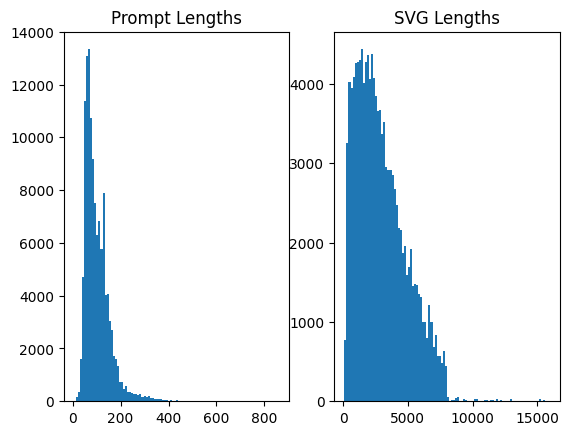

In [88]:
# Original Distribution
prompt_lengths = final_combined_df['prompt'].apply(lambda x : len(x))
svg_lengths = final_combined_df['svg'].apply(lambda x : len(x))
fig, ax = plt.subplots(1, 2)
ax[0].hist(prompt_lengths, bins=100)
ax[0].set_title('Prompt Lengths')
ax[1].hist(svg_lengths, bins=100)
ax[1].set_title('SVG Lengths')
plt.show()

In [89]:
token_len_final_combined_df = final_combined_df[final_combined_df['svg'].apply(lambda x : len(x) < 4700)]
token_len_final_combined_df = token_len_final_combined_df[token_len_final_combined_df['prompt'].apply(lambda x : len(x) <= 200)]
token_len_final_combined_df
# Final total input to model should be less than 5000, > 4700 + 200 = 4900
# margin for special tokens and other prompt set ups, 100 chars

,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth an...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,919a7da8bd44dc7781dbe87383a268cc,The image displays a black icon with a photo-l...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
4,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like...,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24..."
5,d342c3ca-4c5a-492f-9a93-1604bcb9a4b2,An arrow pointing right emerges from a line lo...,"<svg fill=""none"" height=""128"" viewBox=""0 0 24 ..."
...,...,...,...
62770,e82d9e43-6b41-4771-96a8-35fa2b57522b,The image features a geometric design primaril...,"<svg height=""128"" preserveAspectRatio=""xMidYMi..."
3392,29917cdfa3be709bb2db71180b39d682,A green circular icon featuring a pair of shor...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
70660,7b8067bfb7f20d3a72482f9c6deee631,A simple purple padlock icon with an open shac...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2874,daa81e5e78c87c98cc612672a03406b9,A simple line drawing of a building with a cro...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


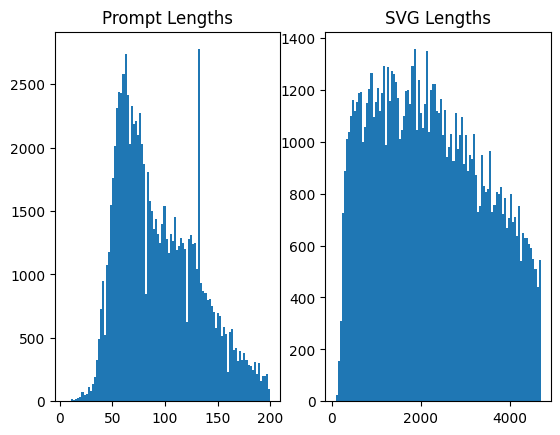

In [90]:
# New Distribution
prompt_lengths = token_len_final_combined_df['prompt'].apply(lambda x : len(x))
svg_lengths = token_len_final_combined_df['svg'].apply(lambda x : len(x))
fig, ax = plt.subplots(1, 2)
ax[0].hist(prompt_lengths, bins=100)
ax[0].set_title('Prompt Lengths')
ax[1].hist(svg_lengths, bins=100)
ax[1].set_title('SVG Lengths')
plt.show()

In [91]:
get_color_dist(token_len_final_combined_df, 'token_len_final_combined_df')

token_len_final_combined_df:  black 21692
token_len_final_combined_df:  white 21750
token_len_final_combined_df:  grey 199
token_len_final_combined_df:  gray 10095
token_len_final_combined_df:  red 12449
token_len_final_combined_df:  blue 17594
token_len_final_combined_df:  orange 8382
token_len_final_combined_df:  yellow 9764
token_len_final_combined_df:  green 8081
token_len_final_combined_df:  purple 8336
token_len_final_combined_df:  pink 8019


In [92]:
token_len_final_combined_df.to_csv('./dataset/final_df.csv')